# Support Vector Machines

Support Vector Machine (SVM) is a supervised machine learning algorithm
used mainly for classification and regression problems.

The main idea of SVM is to find a decision boundary that separates classes
while maximizing the margin between the classes.

SVM is especially useful when:

- The number of features is large
- The dataset is relatively small or medium-sized
- Classes have a clear separation
- A non-linear decision boundary is required

In this notebook, we will understand SVM from intuition to mathematics
and then implement it using scikit-learn.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score
)

## What is Support Vector Machine?

Support Vector Machine (SVM) is a supervised learning algorithm that
finds a decision boundary, called a hyperplane, that separates different
classes.

The key objective of SVM is not simply to separate the classes.

Instead, SVM tries to find the separating hyperplane with the
**maximum possible margin**.

The observations closest to the decision boundary are called
**support vectors**.

Therefore:

    SVM = Hyperplane + Maximum Margin + Support Vectors
    

## Intuition Behind SVM

Suppose we have two classes of observations.

There may be many possible lines that can separate the two classes.

However, SVM chooses the line that provides the largest distance
between the decision boundary and the closest observations from
each class.

This distance is called the **margin**.

A larger margin generally provides better generalization to unseen data.

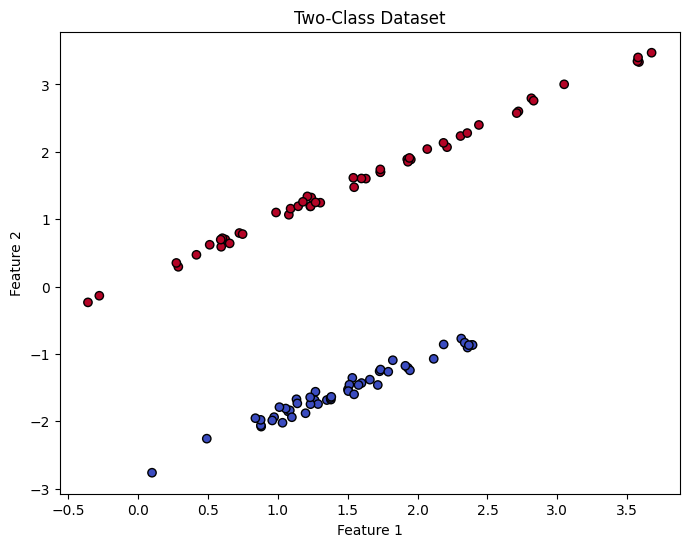

In [2]:
X, y = make_classification(
    n_samples=100,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Class Dataset")

plt.show()

## Hyperplane

A hyperplane is a decision boundary used to separate classes.

For two-dimensional data, the hyperplane is a line:

    w₁x₁ + w₂x₂ + b = 0

where:

- w₁ and w₂ are model weights
- x₁ and x₂ are input features
- b is the bias/intercept

The prediction depends on which side of the hyperplane
an observation lies.

For binary classification:

    wᵀx + b > 0  → Class +1

    wᵀx + b < 0  → Class -1

## Margin

The margin is the distance between the decision boundary and
the closest observations from each class.

SVM attempts to maximize this margin.

The two margin boundaries can be written as:

    wᵀx + b = +1

    wᵀx + b = -1

The distance between these two boundaries is:

                 2
    Margin = -----------
                ||w||

Therefore, maximizing the margin is equivalent to minimizing:

    ||w||² / 2

## Support Vectors

Support vectors are the observations that lie closest to the
decision boundary.

They are extremely important because they determine the position
of the optimal separating hyperplane.

Observations far away from the decision boundary usually have
little or no influence on the final boundary.

Therefore:

    Support Vectors
            ↓
    Determine the margin
            ↓
    Determine the decision boundary

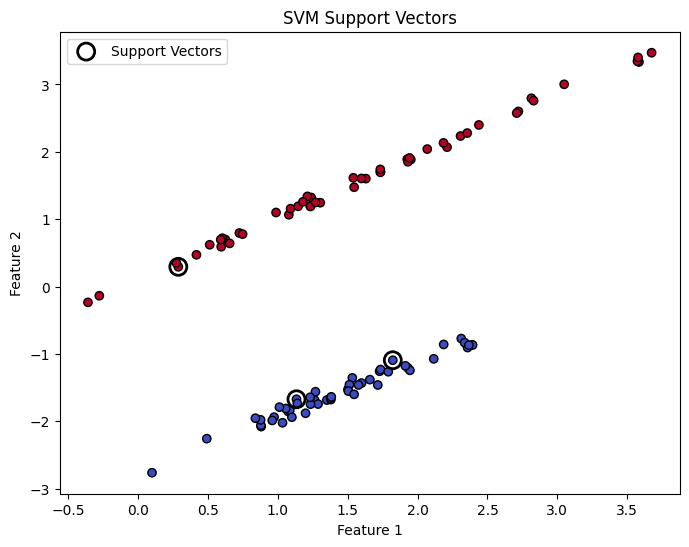

In [3]:
svm_model = SVC(kernel="linear", C=1)
svm_model.fit(X, y)

support_vectors = svm_model.support_vectors_

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    edgecolor="k"
)

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("SVM Support Vectors")

plt.legend()
plt.show()

## Maximum Margin Classifier

For a perfectly linearly separable dataset, SVM attempts to find:

    The hyperplane that maximizes the margin.

For the canonical formulation:

    yᵢ(wᵀxᵢ + b) ≥ 1

for every training observation.

The optimization problem becomes:

    Minimize:

            1
            ─ ||w||²
            2

    Subject to:

            yᵢ(wᵀxᵢ + b) ≥ 1

The objective is to find the smallest possible ||w||,
which produces the largest possible margin.

## Hard Margin SVM

Hard Margin SVM assumes that the training data can be perfectly
separated by a hyperplane.

The constraint is:

    yᵢ(wᵀxᵢ + b) ≥ 1

for every training observation.

This means:

- No classification errors are allowed
- No observations are allowed inside the margin

Hard Margin SVM works well only when the classes are clearly
separable and there are few or no outliers.

In real-world datasets, perfect separation is often unrealistic.

Therefore, we usually use **Soft Margin SVM**.

## Soft Margin SVM

Soft Margin SVM allows some observations to violate the margin.

Slack variables ξᵢ are introduced:

    yᵢ(wᵀxᵢ + b) ≥ 1 - ξᵢ

where:

    ξᵢ ≥ 0

The optimization objective becomes:

    Minimize:

            1
            ─ ||w||² + C Σξᵢ
            2

The parameter C controls the trade-off between:

- A large margin
- Classification errors

## The C Parameter

C controls how strongly the model penalizes classification errors.

### Large C

A large C means:

    Misclassification is heavily penalized.

The model tries harder to classify training observations correctly.

This can produce:

- Smaller margin
- More complex decision boundary
- Greater risk of overfitting

### Small C

A small C means:

    Some classification errors are acceptable.

The model prefers a wider margin.

This can produce:

- Larger margin
- Simpler decision boundary
- Greater regularization

## Feature Scaling

Feature scaling is particularly important for SVM.

SVM relies on distances and the geometry of the feature space.

Suppose:

    Feature 1 → values between 0 and 1

    Feature 2 → values between 0 and 100000

Feature 2 can dominate the geometry of the model.

Therefore, numerical features should usually be standardized.

Standardization:

    z = (x - μ) / σ

where:

- μ = mean
- σ = standard deviation

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Linear SVM Classification

When the classes can be separated approximately by a straight line,
we can use a linear kernel.

In scikit-learn:

    SVC(kernel="linear")

The main parameter is C.

In [5]:
linear_svm = SVC(
    kernel="linear",
    C=1
)

linear_svm.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Predictions

In [6]:
y_pred = linear_svm.predict(X_test_scaled)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


## Classification Report

In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## Decision Boundary

For a two-dimensional dataset, we can visualize the decision boundary
learned by the SVM.

The decision function is:

    f(x) = wᵀx + b

The boundary occurs where:

    f(x) = 0

In [9]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        Z,
        alpha=0.2,
        cmap="coolwarm"
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k"
    )

    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=150,
        facecolors="none",
        edgecolors="black",
        linewidths=2,
        label="Support Vectors"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

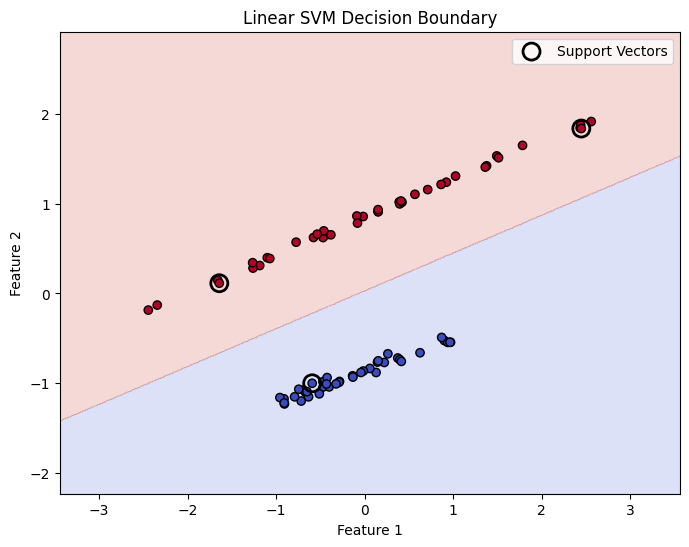

In [11]:
plot_decision_boundary(
    linear_svm,
    X_train_scaled,
    y_train,
    "Linear SVM Decision Boundary"
)

## Non-Linear Classification

Not every dataset can be separated using a straight line.

For example, consider a circular dataset.

A linear classifier cannot create a suitable boundary.

SVM can handle such problems using the **kernel trick**.

Common kernels include:

1. Linear
2. Polynomial
3. RBF
4. Sigmoid

## Create a Non-Linear Dataset

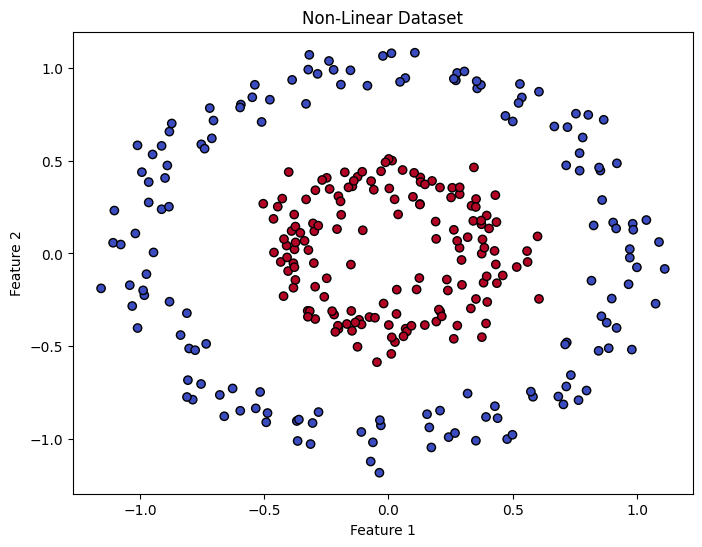

In [12]:
from sklearn.datasets import make_circles

X_circle, y_circle = make_circles(
    n_samples=300,
    noise=0.08,
    factor=0.4,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_circle[:, 0],
    X_circle[:, 1],
    c=y_circle,
    cmap="coolwarm",
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Non-Linear Dataset")

plt.show()

## Why Linear SVM Fails

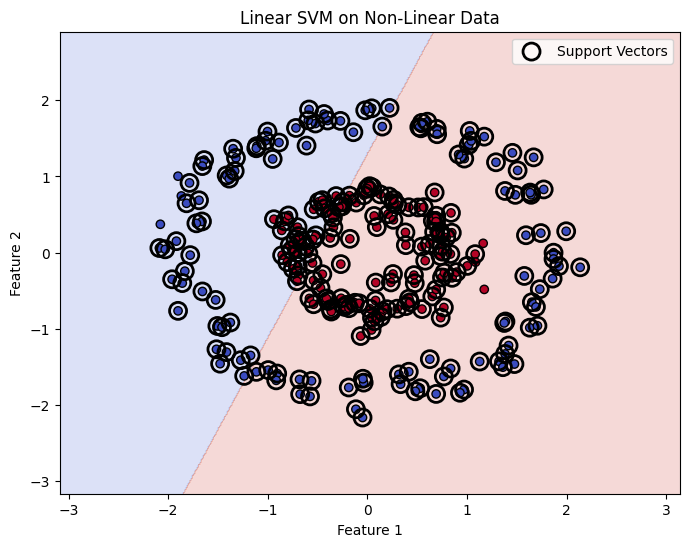

In [13]:
X_train_circle, X_test_circle, y_train_circle, y_test_circle = train_test_split(
    X_circle,
    y_circle,
    test_size=0.2,
    random_state=42,
    stratify=y_circle
)

scaler_circle = StandardScaler()

X_train_circle_scaled = scaler_circle.fit_transform(X_train_circle)
X_test_circle_scaled = scaler_circle.transform(X_test_circle)

linear_circle_svm = SVC(
    kernel="linear",
    C=1
)

linear_circle_svm.fit(
    X_train_circle_scaled,
    y_train_circle
)

plot_decision_boundary(
    linear_circle_svm,
    X_train_circle_scaled,
    y_train_circle,
    "Linear SVM on Non-Linear Data"
)

## Kernel Trick

The kernel trick allows SVM to model non-linear relationships
without explicitly transforming the original data into a
high-dimensional feature space.

Instead of directly computing:

    φ(xᵢ)ᵀ φ(xⱼ)

SVM uses a kernel function:

    K(xᵢ, xⱼ)

This allows the algorithm to work as if the data had been
transformed into a higher-dimensional space.

This is one of the most important ideas behind SVM.

Common kernels:

    Linear
    Polynomial
    RBF
    Sigmoid

## Polynomial Kernel

The polynomial kernel can model polynomial relationships between
features.

A simplified polynomial kernel is:

    K(x, z) = (xᵀz + c)ᵈ

where:

- d = polynomial degree
- c = kernel coefficient

In scikit-learn:

    SVC(kernel="poly")

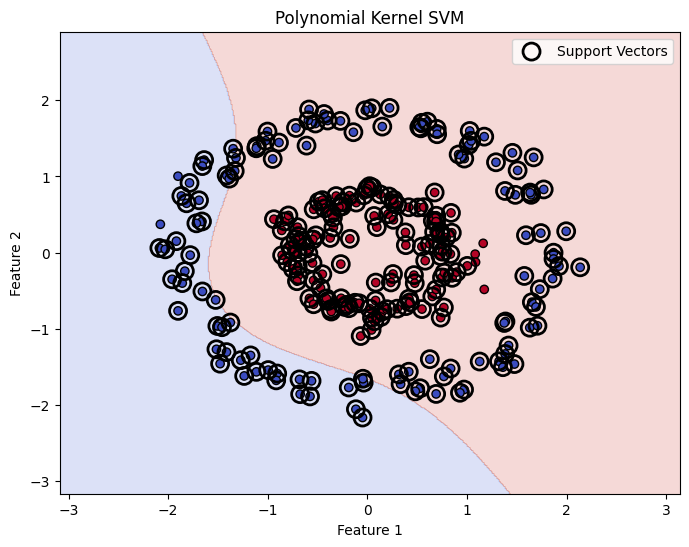

In [14]:
poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1
)

poly_svm.fit(
    X_train_circle_scaled,
    y_train_circle
)

plot_decision_boundary(
    poly_svm,
    X_train_circle_scaled,
    y_train_circle,
    "Polynomial Kernel SVM"
)

## RBF Kernel

The Radial Basis Function (RBF) kernel is one of the most commonly
used kernels for non-linear SVM.

It is defined as:

    K(x, z) = exp(-γ ||x - z||²)

where γ controls how strongly individual observations influence
the decision boundary.

The RBF kernel can create highly flexible non-linear boundaries.

## RBF SVM

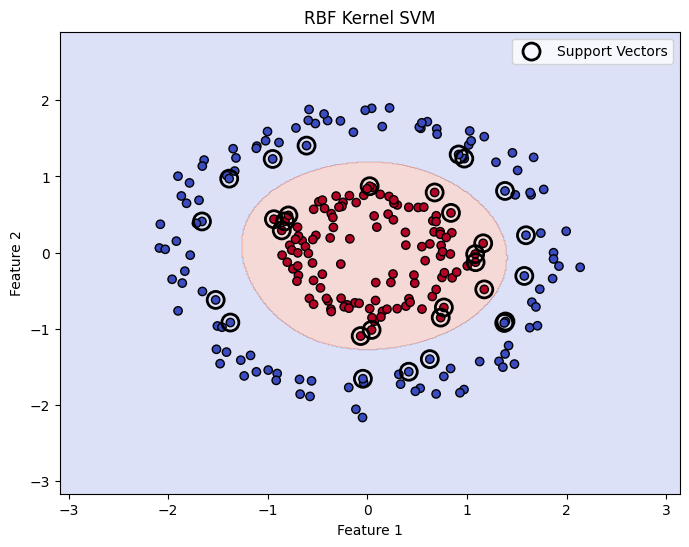

In [15]:
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(
    X_train_circle_scaled,
    y_train_circle
)

plot_decision_boundary(
    rbf_svm,
    X_train_circle_scaled,
    y_train_circle,
    "RBF Kernel SVM"
)

## Gamma Parameter

Gamma controls the influence of a single training observation.

### High Gamma

A high gamma means each observation has a small region of influence.

The decision boundary becomes more complex.

Possible result:

    High variance → Overfitting

### Low Gamma

A low gamma means each observation influences a larger region.

The decision boundary becomes smoother.

Possible result:

    High bias → Underfitting

Therefore:

    Low gamma  → smoother boundary

    High gamma → more complex boundary

## Compare Gamma Values

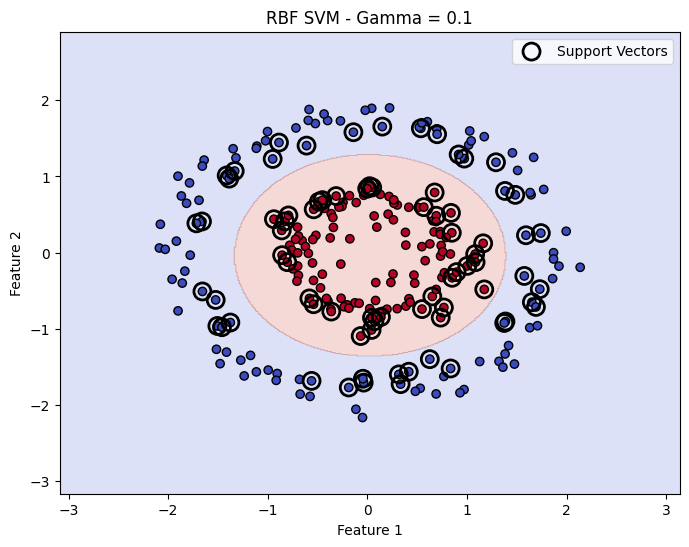

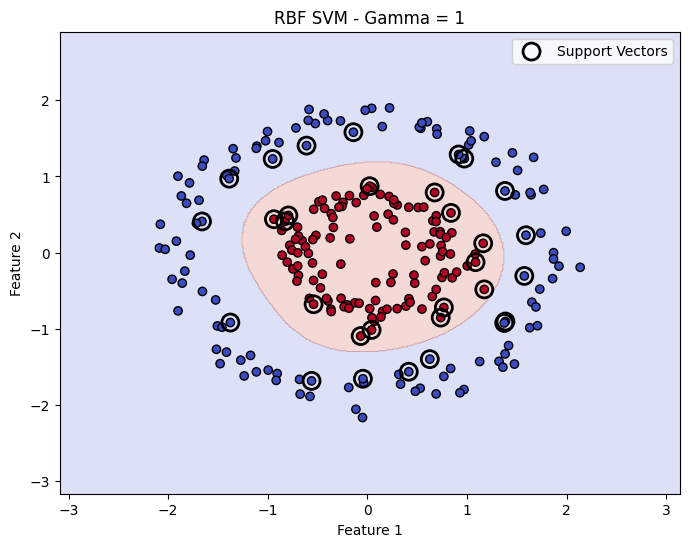

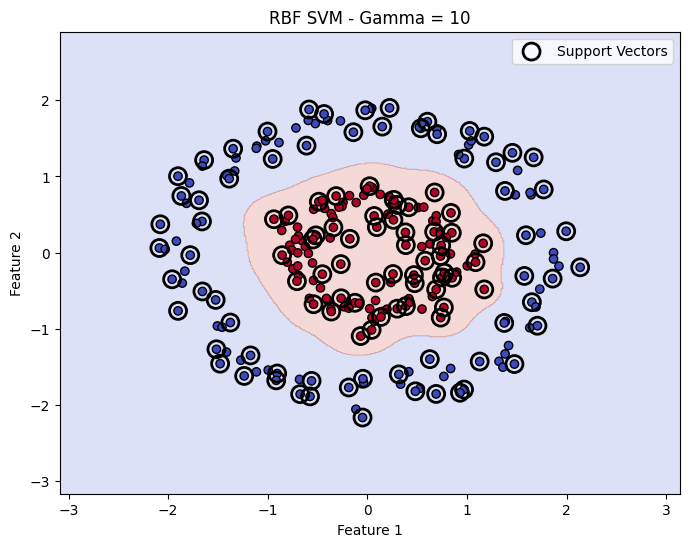

In [16]:
gamma_values = [0.1, 1, 10]

for gamma in gamma_values:

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma
    )

    model.fit(
        X_train_circle_scaled,
        y_train_circle
    )

    plot_decision_boundary(
        model,
        X_train_circle_scaled,
        y_train_circle,
        f"RBF SVM - Gamma = {gamma}"
    )

## Compare Different C Values

## Effect of C

The C parameter controls the strength of the penalty for
classification errors.

We can compare different values:

    C = 0.1
    C = 1
    C = 10
    C = 100

Increasing C generally makes the model focus more strongly
on correctly classifying the training observations.

In [17]:
C_values = [0.1, 1, 10, 100]

for C in C_values:

    model = SVC(
        kernel="rbf",
        C=C,
        gamma="scale"
    )

    model.fit(
        X_train_circle_scaled,
        y_train_circle
    )

    print(
        f"C = {C}, "
        f"Train Accuracy = {model.score(X_train_circle_scaled, y_train_circle):.3f}, "
        f"Test Accuracy = {model.score(X_test_circle_scaled, y_test_circle):.3f}"
    )

C = 0.1, Train Accuracy = 1.000, Test Accuracy = 1.000
C = 1, Train Accuracy = 1.000, Test Accuracy = 1.000
C = 10, Train Accuracy = 1.000, Test Accuracy = 1.000
C = 100, Train Accuracy = 1.000, Test Accuracy = 1.000


## Important SVM Hyperparameters

### C

Controls the penalty for classification errors.

    Small C → wider margin, more regularization

    Large C → narrower margin, less regularization

### kernel

Determines the type of decision boundary.

Common choices:

    "linear"
    "poly"
    "rbf"
    "sigmoid"

### gamma

Controls the influence of individual observations for kernels
such as RBF and polynomial.

    Small gamma → smoother boundary

    Large gamma → more complex boundary

### degree

Controls the polynomial degree when:

    kernel="poly"

## SVM Regression

SVM can also be used for regression.

The regression version is called:

    Support Vector Regression (SVR)

Instead of trying to separate classes, SVR attempts to fit a function
while allowing errors within a specified tolerance.

The tolerance parameter is:

    ε (epsilon)

Observations within the epsilon-tube are not penalized.

Observations outside the tube contribute to the loss.

## Create Regression Dataset

In [18]:
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(
    n_samples=150,
    n_features=1,
    noise=15,
    random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

## Training an SVR Model

We can use `SVR` from scikit-learn for Support Vector Regression.

Important parameters include:

- C
- epsilon
- kernel
- gamma

In [19]:
svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

svr_model.fit(
    X_train_reg_scaled,
    y_train_reg
)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## SVR Predictions

In [20]:
y_pred_reg = svr_model.predict(
    X_test_reg_scaled
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MSE : 197.28785613518954
RMSE: 14.045919554631855
R²  : 0.9629734734905051


## SVR Visualization

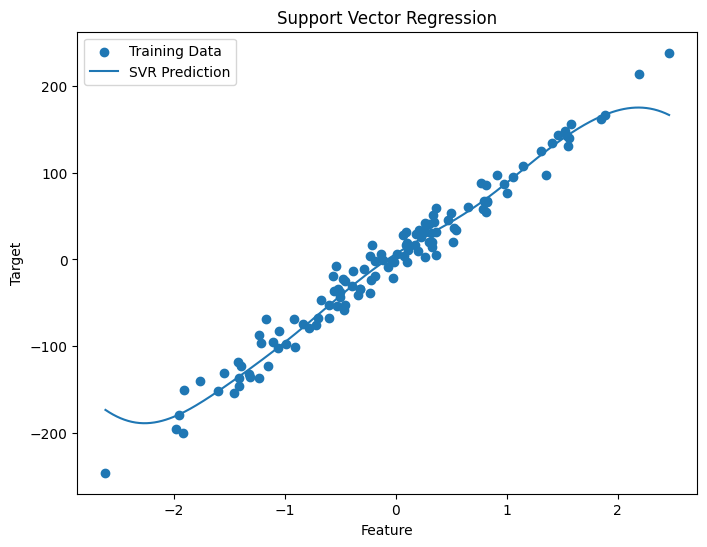

In [21]:
X_plot = np.linspace(
    X_reg.min(),
    X_reg.max(),
    300
).reshape(-1, 1)

X_plot_scaled = scaler_reg.transform(X_plot)

y_plot = svr_model.predict(
    X_plot_scaled
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_reg,
    y_train_reg,
    label="Training Data"
)

plt.plot(
    X_plot,
    y_plot,
    label="SVR Prediction"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Support Vector Regression")

plt.legend()
plt.show()

## Practical Example: SVM Classification

Now we will build a complete SVM classification workflow.

The workflow is:

1. Load dataset
2. Split into training and testing sets
3. Scale the features
4. Create the SVM model
5. Train the model
6. Make predictions
7. Evaluate the model

In [22]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


## Train-Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Train SVM

In [25]:
svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

svm_model.fit(
    X_train_scaled,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Make Predictions

In [26]:
y_pred = svm_model.predict(
    X_test_scaled
)

print(y_pred[:20])

[0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1]


## Evaluate the Model

In [27]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9824561403508771


In [28]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [29]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[41  1]
 [ 1 71]]


## Advantages of SVM

1. Works well in high-dimensional spaces.

2. Effective when the number of features is large compared with
   the number of observations.

3. Can model both linear and non-linear relationships.

4. The kernel trick allows complex decision boundaries.

5. Uses support vectors, which makes the final model dependent
   mainly on important observations near the decision boundary.

6. Can be used for both classification and regression.


## Limitations of SVM

1. SVM can be computationally expensive for very large datasets.

2. Feature scaling is usually important.

3. Choosing the right kernel can be difficult.

4. Hyperparameters such as C and gamma can strongly affect performance.

5. SVM models are generally less interpretable than simple
   linear models.

6. The model can be sensitive to noisy data and outliers.

## SVM vs Logistic Regression

| Property | Logistic Regression | SVM |
|---|---|---|
| Main task | Classification | Classification + Regression |
| Linear boundary | Yes | Yes |
| Non-linear boundary | With feature engineering | With kernels |
| Output | Probabilities naturally | Decision scores |
| Margin maximization | No | Yes |
| Kernel trick | No | Yes |
| Interpretability | Relatively high | Lower |
| Large datasets | Usually efficient | Can be expensive |

Logistic Regression focuses on estimating class probabilities.

SVM focuses on finding a separating boundary with a large margin.

## SVM and Overfitting

SVM can overfit when the decision boundary becomes too flexible.

Two important parameters control model complexity:

    C
    gamma

Increasing C can make the model focus more strongly on training errors.

Increasing gamma can make an RBF decision boundary more localized
and complex.

Therefore, both parameters should usually be selected using
validation or cross-validation rather than guessing arbitrary values.

# Summary

In this notebook, we learned:

- What Support Vector Machines are
- Hyperplanes
- Margins
- Support vectors
- Maximum margin classification
- Hard Margin SVM
- Soft Margin SVM
- The C parameter
- Why feature scaling is important
- Linear SVM
- Non-linear classification
- Kernel trick
- Polynomial kernel
- RBF kernel
- Gamma parameter
- SVM hyperparameters
- Support Vector Regression (SVR)
- Practical SVM classification
- Advantages and limitations

The central idea of SVM is:

    Find a decision boundary that separates the classes
    while maximizing the margin.

For non-linear problems:

    Use the kernel trick.

The most important parameters to remember are:

    C      → controls regularization / penalty for errors

    gamma  → controls influence of individual observations

    kernel → controls the type of decision boundary

    degree → controls polynomial complexity